# Worksheet 5 — End-to-End CNN for Fruit in Amazon
This notebook completes the worksheet tasks for building, training, evaluating, saving, loading, and reporting a CNN image classifier for the Fruit in Amazon dataset.

**What this notebook covers**
1. Data understanding and visualization  
2. Corrupted image check  
3. Loading and preprocessing with `image_dataset_from_directory`  
4. CNN implementation using the required structure  
5. Model compilation and training  
6. Evaluation on the test set  
7. Save and load the model  
8. Predictions and classification report

> The notebook follows the worksheet requirements for directory-based loading, CNN architecture, training with callbacks, evaluation, and final classification report.

In [1]:
# =========================
# 1. Imports
# =========================
import os
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Locate and extract the dataset zip
This cell looks for `FruitinAmazon.zip` in common notebook locations.

If you are using **Google Colab**, upload the zip file first to the Files panel or run the optional upload cell below.


In [2]:
# OPTIONAL: Uncomment this only if you are in Google Colab and need to upload the zip manually.
# from google.colab import files
# uploaded = files.upload()

In [3]:
# =========================
# 2. Locate and extract the dataset
# =========================
possible_zip_paths = [
    Path("FruitinAmazon.zip"),
    Path("/content/FruitinAmazon.zip"),
    Path("/mnt/data/FruitinAmazon.zip"),
]

zip_path = None
for p in possible_zip_paths:
    if p.exists():
        zip_path = p
        break

if zip_path is None:
    raise FileNotFoundError(
        "FruitinAmazon.zip was not found. Upload it to the notebook folder and run this cell again."
    )

extract_dir = zip_path.parent / "FruitinAmazon_extracted"

if extract_dir.exists():
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

base_dir = extract_dir / "FruitinAmazon"
train_dir = base_dir / "train"
test_dir = base_dir / "test"

if not train_dir.exists() or not test_dir.exists():
    raise FileNotFoundError("Expected train/ and test/ folders were not found after extraction.")

print("Zip path:", zip_path)
print("Extracted to:", extract_dir)
print("Train dir:", train_dir)
print("Test dir:", test_dir)

Zip path: FruitinAmazon.zip
Extracted to: FruitinAmazon_extracted
Train dir: FruitinAmazon_extracted/FruitinAmazon/train
Test dir: FruitinAmazon_extracted/FruitinAmazon/test


## 3. Task 1 — Data understanding and visualization
The worksheet asks to:
- get the class directories from the training folder,
- select one random image from each class,
- display them in a grid with two rows.


In [4]:
# =================
# 3. Class names and dataset summary
# =================
class_names = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
num_classes = len(class_names)

print("Classes found:", class_names)
print("Number of classes:", num_classes)

print("\nImage counts by split and class")
for split_name, split_dir in [("train", train_dir), ("test", test_dir)]:
    print(f"\n{split_name.upper()}")
    for class_name in class_names:
        count = len(list((split_dir / class_name).glob("*")))
        print(f"  {class_name}: {count}")

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6

Image counts by split and class

TRAIN
  acai: 15
  cupuacu: 15
  graviola: 15
  guarana: 15
  pupunha: 15
  tucuma: 15

TEST
  acai: 5
  cupuacu: 5
  graviola: 5
  guarana: 5
  pupunha: 5
  tucuma: 5


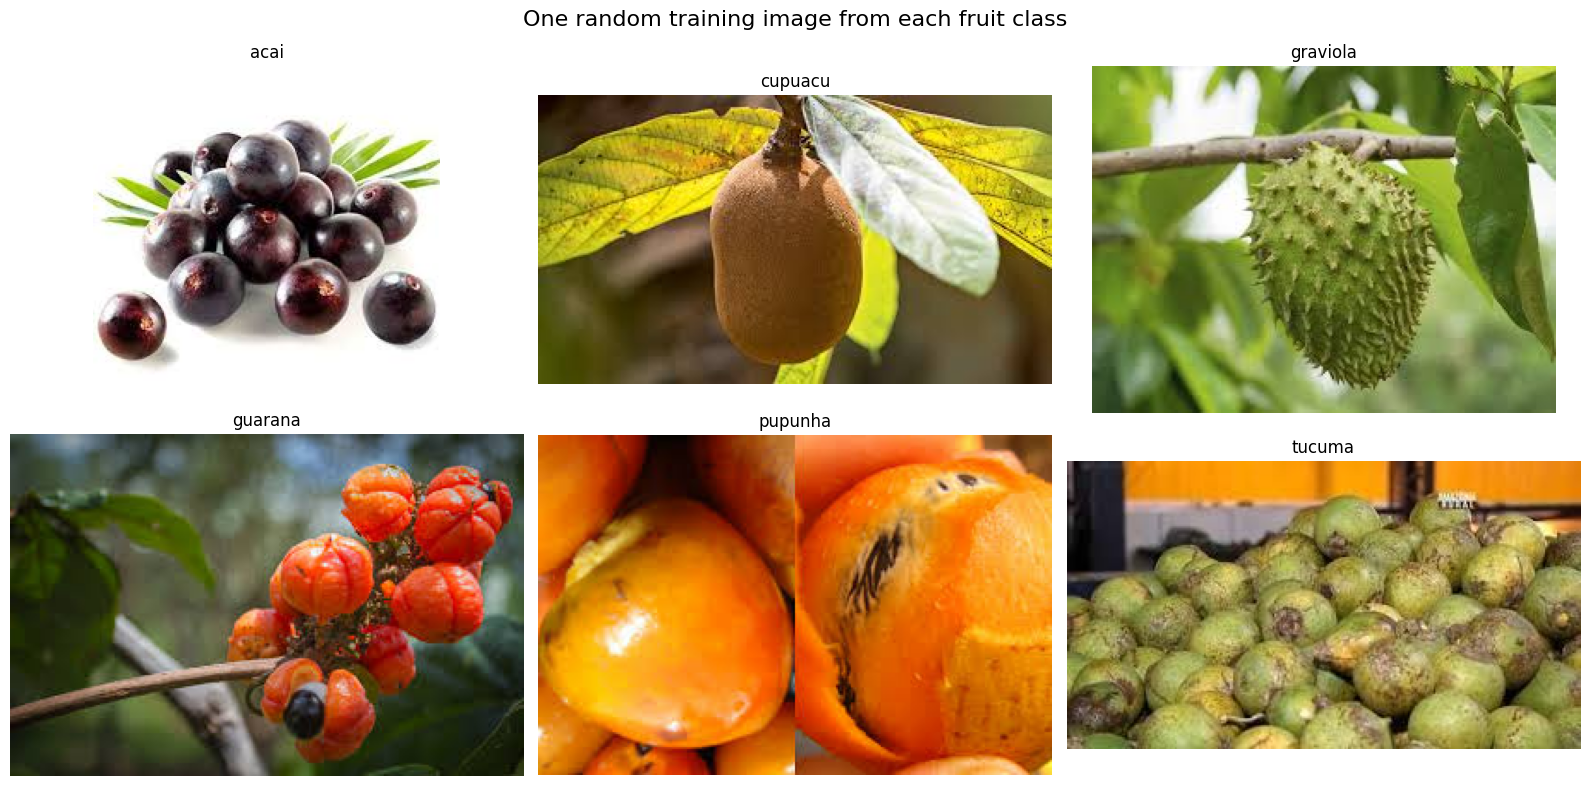

In [5]:
# =========================
# 4. Visualize one random image from each class
# =========================
random.seed(42)

rows = 2
cols = int(np.ceil(len(class_names) / rows))
plt.figure(figsize=(16, 8))

for idx, class_name in enumerate(class_names, start=1):
    class_folder = train_dir / class_name
    image_files = [p for p in class_folder.iterdir() if p.is_file()]
    chosen_image = random.choice(image_files)

    with Image.open(chosen_image) as img:
        plt.subplot(rows, cols, idx)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

plt.suptitle("One random training image from each fruit class", fontsize=16)
plt.tight_layout()
plt.show()

### Observation
The dataset contains **6 fruit classes**: `acai`, `cupuacu`, `graviola`, `guarana`, `pupunha`, and `tucuma`.  
Each class is organized into its own folder, which makes it suitable for Keras directory-based loading.  
The images show visible differences in **shape, color, texture, and background**, which should help the CNN learn discriminative features. At the same time, some classes may still be challenging because image backgrounds and lighting vary across samples.


## 4. Task 1 — Corrupted image check
The worksheet asks to verify every image in the training directory, remove any corrupted files, and print whether corrupted images were found.


In [6]:
# =========================
# 5. Check for corrupted images in the train directory
# =========================
corrupted_images = []

for class_name in class_names:
    class_folder = train_dir / class_name
    for image_path in class_folder.iterdir():
        if image_path.is_file():
            try:
                with Image.open(image_path) as img:
                    img.verify()  # verifies whether the file is a valid image
            except (IOError, SyntaxError, OSError) as e:
                corrupted_images.append(str(image_path))
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print("\nTotal corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


## 5. Task 2 — Load and preprocess image data in Keras
The worksheet specifies loading images from directories, resizing, batching, and normalization using Keras utilities.


In [7]:
# =========================
# 6. Image loading and preprocessing
# =========================
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

# Normalize pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Improve input pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Class names from dataset:", train_ds.class_names if hasattr(train_ds, "class_names") else class_names)
print("Image size:", (img_height, img_width))
print("Batch size:", batch_size)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names from dataset: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Image size: (128, 128)
Batch size: 16


In [8]:
# Inspect one batch
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)
First 10 labels: [1 0 5 4 4 5 2 3 0 4]


## 6. Task 3 — Build the CNN
The worksheet requests:
- Conv2D(32, 3x3, padding='same', stride=1) + ReLU
- MaxPooling2D(2x2, stride=2)
- Conv2D(32, 3x3, padding='same', stride=1) + ReLU
- MaxPooling2D(2x2, stride=2)
- Flatten
- Dense hidden layers with 64 and 128 neurons
- Output layer with `num_classes` neurons.


In [9]:
# =========================
# 7. Build the CNN model
# =========================
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Task 4 — Compile and train the model
The worksheet asks for an appropriate optimizer, sparse categorical cross-entropy loss, accuracy metric, batch size 16, 250 epochs, validation on `val_ds`, and callbacks like `ModelCheckpoint` and `EarlyStopping`.


In [10]:
# =========================
# 8. Compile the model
# =========================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
# =========================
# 9. Train the model
# =========================
checkpoint_path = "best_fruit_cnn_model.h5"

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.1701 - loss: 1.9588
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_cnn_model.h5



Epoch 1: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 816ms/step - accuracy: 0.1944 - loss: 1.9529 - val_accuracy: 0.0000e+00 - val_loss: 2.0468
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1875 - loss: 1.7573
Epoch 2: val_accuracy improved from 0.00000 to 0.05556, saving model to best_fruit_cnn_model.h5



Epoch 2: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2778 - loss: 1.6735 - val_accuracy: 0.0556 - val_loss: 1.7046
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4375 - loss: 1.5747
Epoch 3: val_accuracy did not improve from 0.05556
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5278 - loss: 1.4227 - val_accuracy: 0.0556 - val_loss: 1.7556
Epoch 4/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 1.1932
Epoch 4: val_accuracy improved from 0.05556 to 0.50000, saving model to best_fruit_cnn_model.h5



Epoch 4: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6806 - loss: 1.0636 - val_accuracy: 0.5000 - val_loss: 1.4691
Epoch 5/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7500 - loss: 1.0064
Epoch 5: val_accuracy improved from 0.50000 to 0.72222, saving model to best_fruit_cnn_model.h5



Epoch 5: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8056 - loss: 0.7683 - val_accuracy: 0.7222 - val_loss: 0.9081
Epoch 6/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6875 - loss: 0.7178
Epoch 6: val_accuracy improved from 0.72222 to 0.83333, saving model to best_fruit_cnn_model.h5



Epoch 6: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8472 - loss: 0.4828 - val_accuracy: 0.8333 - val_loss: 0.5644
Epoch 7/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9375 - loss: 0.2576
Epoch 7: val_accuracy improved from 0.83333 to 0.88889, saving model to best_fruit_cnn_model.h5



Epoch 7: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9444 - loss: 0.2313 - val_accuracy: 0.8889 - val_loss: 0.5243
Epoch 8/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8750 - loss: 0.3018
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9306 - loss: 0.1937 - val_accuracy: 0.8889 - val_loss: 0.2746
Epoch 9/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.2370
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9583 - loss: 0.1566 - val_accuracy: 0.6667 - val_loss: 0.7670
Epoch 10/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8125 - loss: 0.2453
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9583 - loss: 0.1056 - val_accuracy: 0.8889 - val_loss: 0.4608
Epoch 11/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 


Epoch 14: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9722 - loss: 0.0699 - val_accuracy: 0.9444 - val_loss: 0.2979
Epoch 15/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0071
Epoch 15: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0377 - val_accuracy: 0.8889 - val_loss: 0.4899
Epoch 16/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0079
Epoch 16: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0123 - val_accuracy: 0.8333 - val_loss: 0.8531
Epoch 17/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0109
Epoch 17: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0238 - val_accuracy: 0.8889 - val_loss: 0.4834
Epoch 18/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - lo

## 8. Training curves
The worksheet expects graphs for training and validation loss and accuracy.


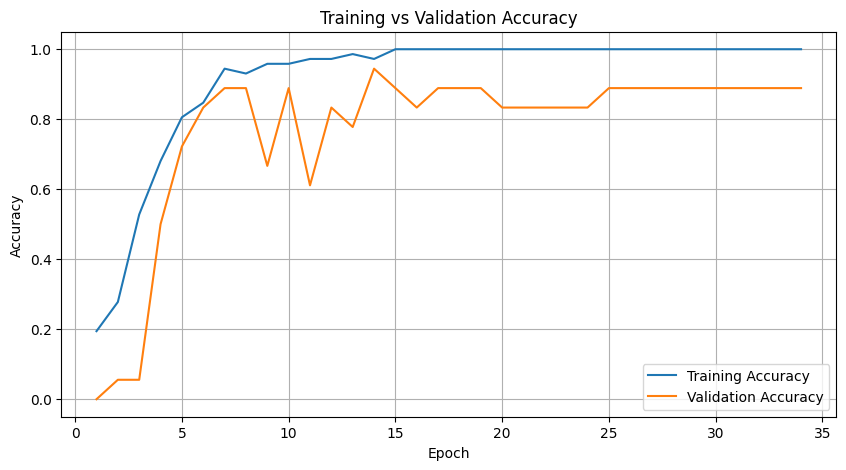

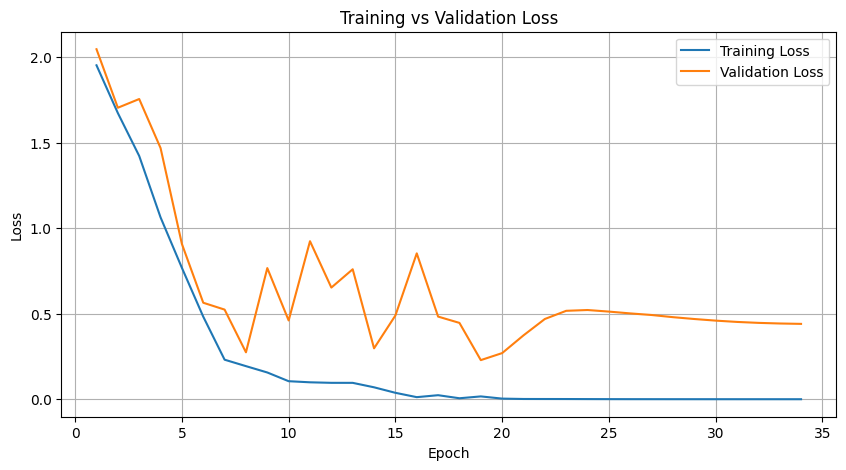

In [12]:
# =========================
# 10. Plot training history
# =========================
history_dict = history.history
epochs_range = range(1, len(history_dict["accuracy"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_dict["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_dict["loss"], label="Training Loss")
plt.plot(epochs_range, history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 9. Task 5 — Evaluate the model on the test set
The worksheet asks to evaluate the trained model on the test set and report accuracy and loss.


In [13]:
# =========================
# 11. Evaluate on test data
# =========================
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step - accuracy: 0.6667 - loss: 1.2044
Test Loss: 1.2044
Test Accuracy: 0.6667


## 10. Task 6 — Save and load the model
The worksheet requires saving the model as an `.h5` file, loading it back, and re-evaluating on the test set.


In [14]:
# =========================
# 12. Save the trained model
# =========================
final_model_path = "fruit_cnn_model.h5"
model.save(final_model_path)
print(f"Model saved to: {final_model_path}")

Model saved to: fruit_cnn_model.h5


In [15]:
# =========================
# 13. Load the saved model and re-evaluate
# =========================
loaded_model = keras.models.load_model(final_model_path)
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds, verbose=1)

print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step - accuracy: 0.6667 - loss: 1.2044
Loaded Model Test Loss: 1.2044
Loaded Model Test Accuracy: 0.6667


## 11. Task 7 — Predictions and classification report
The worksheet asks for:
- `model.predict()` on test images,
- conversion to labels with `np.argmax()`,
- a final classification report.


In [16]:
# =========================
# 14. Predictions on the test set
# =========================
y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    predictions = model.predict(batch_images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(batch_labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (30,)
Predicted labels shape: (30,)


In [17]:
# =========================
# 15. Classification report
# =========================
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.50      1.00      0.67         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.75      0.60      0.67         5
     guarana       0.67      0.80      0.73         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.72      0.67      0.66        30
weighted avg       0.72      0.67      0.66        30



In [18]:
# OPTIONAL: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[5 0 0 0 0 0]
 [0 3 1 0 0 1]
 [2 0 3 0 0 0]
 [1 0 0 4 0 0]
 [0 0 0 2 3 0]
 [2 0 0 0 1 2]]


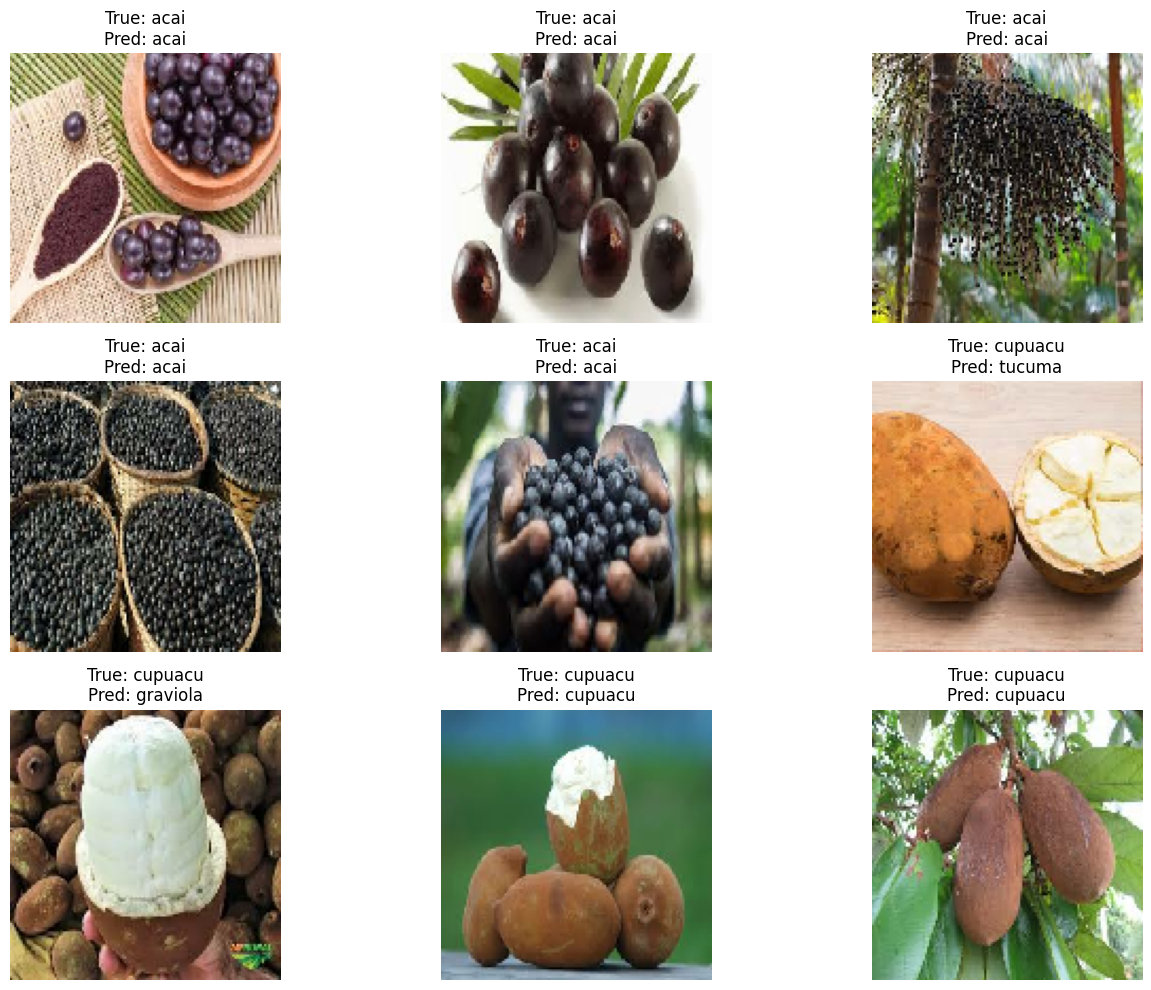

In [19]:
# =========================
# 16. Show a few sample predictions
# =========================
plt.figure(figsize=(14, 10))

sample_images = []
sample_true = []
sample_pred = []

for batch_images, batch_labels in test_ds.take(1):
    predictions = model.predict(batch_images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    sample_images = batch_images.numpy()
    sample_true = batch_labels.numpy()
    sample_pred = predicted_labels

num_show = min(9, len(sample_images))

for i in range(num_show):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"True: {class_names[sample_true[i]]}\nPred: {class_names[sample_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Final notes
- This notebook is ready to run end-to-end.
- The dataset is small, so the model may begin to overfit if trained too long.
- `EarlyStopping` helps stop training once validation performance stops improving.
- The best model during training is also saved as `best_fruit_cnn_model.h5`.

### Files produced after running
- `best_fruit_cnn_model.h5`
- `fruit_cnn_model.h5`

### Suggested submission items
1. This notebook  
2. Screenshots or outputs of training curves  
3. Final classification report  
4. Saved `.h5` model
